In [ ]:
# Entrainement evaluation et correction d'un modèle ML baisé

## Création d'un Data set biaisé

In [2]:
import pandas as pd
import numpy as np

# Initialisation
np.random.seed(42)
n_samples = 2000

# 1. Génération des features avec des distributions réalistes
genre = np.random.choice(['Homme', 'Femme'], size=n_samples, p=[0.65, 0.35]) # Sur-représentation masculine à la candidature
age = np.random.choice(['20-30', '30-40', '40-50', '50+'], size=n_samples, p=[0.35, 0.35, 0.20, 0.10])
ville = np.random.choice(['Paris', 'Marseille', 'Lyon', 'Lille'], size=n_samples, p=[0.40, 0.25, 0.20, 0.15])
diplome = np.random.choice(['A', 'B', 'C'], size=n_samples, p=[0.25, 0.45, 0.30])

df = pd.DataFrame({
    'Genre': genre,
    'Age': age,
    'Ville': ville,
    'Diplôme': diplome
})

# 2. Définition des règles de décision avec intégration des biais
def calculer_probabilite_embauche(row):
    # Score de base
    score = 0.2
    
    # Critère légitime : Le diplôme (A est le meilleur)
    if row['Diplôme'] == 'A':
        score += 0.40
    elif row['Diplôme'] == 'B':
        score += 0.20
        
    # Biais 1 : Sur-représentation / Avantage masculin à l'embauche
    if row['Genre'] == 'Homme':
        score += 0.15
        
    # Biais 2 : Discrimination par âge (pénalise les seniors, favorise les jeunes)
    if row['Age'] == '20-30':
        score += 0.10
    elif row['Age'] == '30-40':
        score += 0.05
    elif row['Age'] == '40-50':
        score -= 0.15
    elif row['Age'] == '50+':
        score -= 0.30
        
    # Biais 3 : Avantage géographique pour Paris
    if row['Ville'] == 'Paris':
        score += 0.20
        
    # Ajout d'un bruit aléatoire pour simuler l'incertitude humaine (entretien, soft skills)
    bruit = np.random.normal(0, 0.05)
    score += bruit
    
    # Ramener la probabilité entre 0 et 1
    return np.clip(score, 0, 1)

# 3. Application des probabilités et tirage de la variable cible
probabilites = df.apply(calculer_probabilite_embauche, axis=1)
df['Embauche'] = np.random.binomial(n=1, p=probabilites)

#### Visualisation des Biais

C:\Users\boniv\AppData\Local\Temp\ipykernel_3124\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
C:\Users\boniv\AppData\Local\Temp\ipykernel_3124\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
C:\Users\boniv\AppData\Local\Temp\ipykernel_3124\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette=

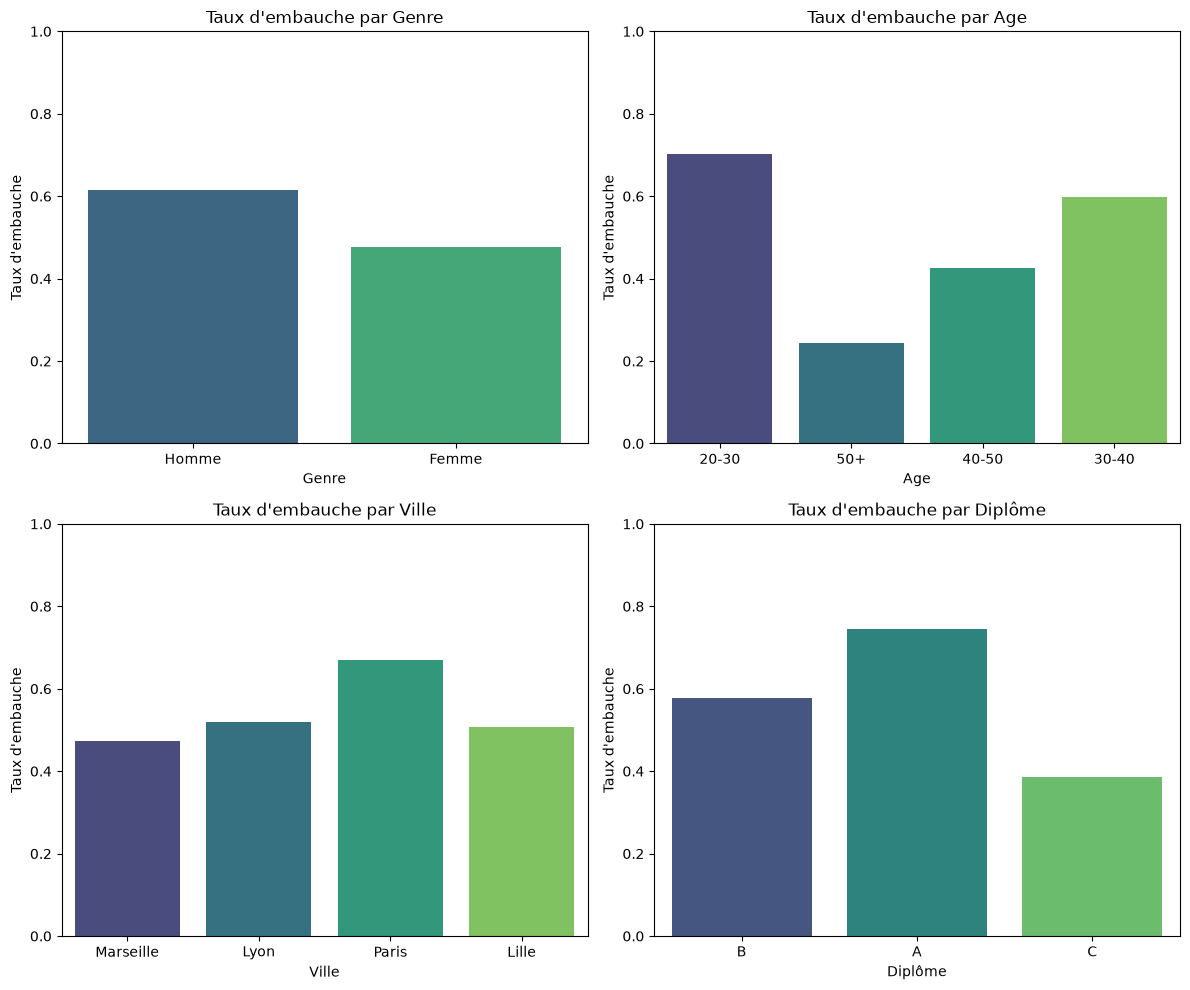

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Genre', 'Age', 'Ville', 'Diplôme']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
    ax.set_title(f"Taux d'embauche par {feature}")
    ax.set_ylabel("Taux d'embauche")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Les diagrammes en barres (bar charts) sont les plus pertinents. Ils permettent de comparer visuellement et directement les proportions (taux d'embauche moyen, qui correspond à la moyenne d'une variable binaire 0/1) entre différentes modalités de variables catégorielles

In [4]:
features = ['Genre', 'Age', 'Ville', 'Diplôme']
metriques = {}

for col in features:
    taux = df.groupby(col)['Embauche'].mean()
    ecart_type = taux.std()
    range_global = taux.max() - taux.min()
    metriques[col] = {'Ecart-type': ecart_type, 'Range (Max-Min)': range_global}
    
df_metriques = pd.DataFrame(metriques).T
print(df_metriques)

         Ecart-type  Range (Max-Min)
Genre      0.098490         0.139285
Age        0.201493         0.460004
Ville      0.087306         0.196584
Diplôme    0.180153         0.360010
